In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("marketing_sales_data.csv")

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
print(df.shape)

df.info()

df.describe()

(572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [4]:
df.isnull().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

In [5]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [6]:
df_encoded = pd.get_dummies(
    df,
    columns=["TV", "Influencer"],
    drop_first=True
)

df_encoded = df_encoded.astype(float)

df_encoded.head()

,Radio,Social Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,1.0,0.0,0.0,1.0,0.0
1,7.756876,2.572287,67.574904,1.0,0.0,1.0,0.0,0.0
2,20.348988,1.227180,272.250108,0.0,0.0,0.0,1.0,0.0
3,20.108487,2.728374,195.102176,0.0,1.0,1.0,0.0,0.0
4,31.653200,7.776978,273.960377,0.0,0.0,0.0,0.0,1.0


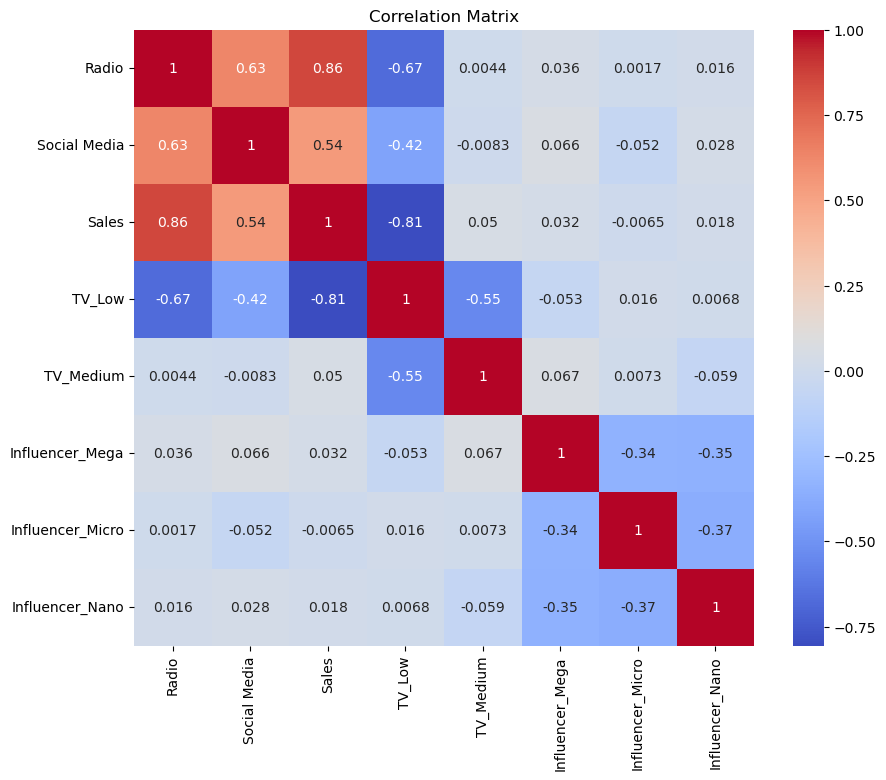

In [7]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [8]:
X_vif = df_encoded.drop("Sales", axis=1)

X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

            Feature        VIF
0             const  31.649565
1             Radio   3.479641
2      Social Media   1.669098
3            TV_Low   4.076384
4         TV_Medium   2.233350
5   Influencer_Mega   1.593889
6  Influencer_Micro   1.618434
7   Influencer_Nano   1.627430


In [9]:
X = df_encoded.drop("Sales", axis=1)

y = df_encoded["Sales"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        10:21:44   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

In [10]:
print("Adjusted R-Squared:", model.rsquared_adj)

Adjusted R-Squared: 0.9030011006551627


In [12]:
predictions = model.predict(X)

residuals = y - predictions

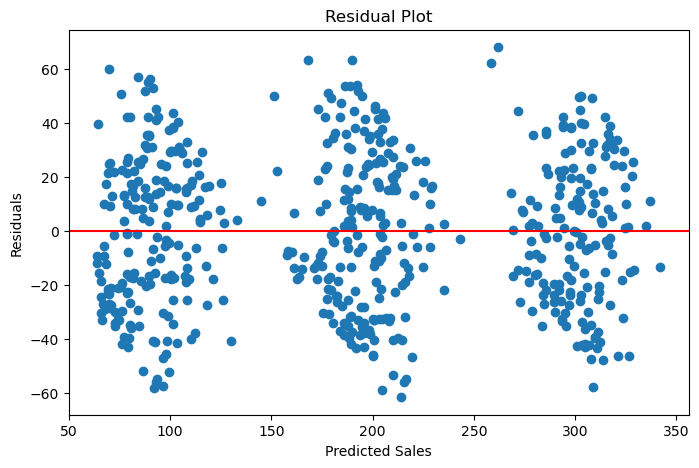

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    predictions,
    residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

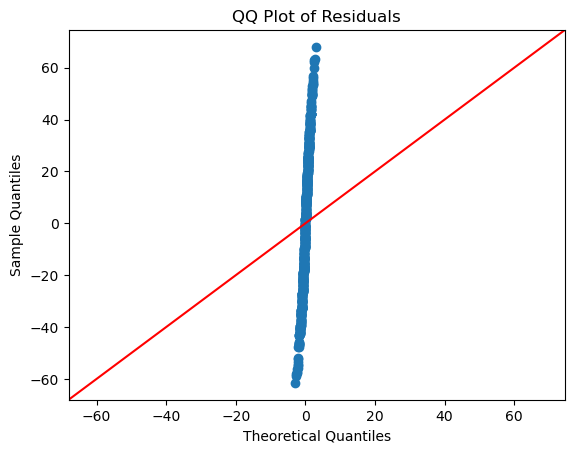

In [16]:
sm.qqplot(
    residuals,
    line="45"
)

plt.title("QQ Plot of Residuals")

plt.show()